# Data Preprocessing
**ShipmentSure — Predicting On-Time Delivery**

A comprehensive preprocessing study benchmarking multiple approaches:
- KNNImputer, IterativeImputer, SimpleImputer for missing values
- RobustScaler, MinMaxScaler, StandardScaler, PowerTransformer, QuantileTransformer
- IsolationForest for anomaly detection
- OrdinalEncoder, FeatureHasher, KBinsDiscretizer
- VarianceThreshold, SelectKBest, PCA for feature reduction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler,
    PowerTransformer, QuantileTransformer,
    OrdinalEncoder, KBinsDiscretizer
)
from sklearn.feature_extraction import FeatureHasher
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 11)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,C,Flight,2,5,306,6,high,M,45,3838,1
1,F,Ship,7,2,114,3,high,M,35,2710,1
2,B,Ship,7,2,215,7,medium,F,44,4152,0
3,A,Road,5,3,126,5,medium,M,54,2245,0
4,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Reached.on.Time_Y.N')
cat_cols = df.select_dtypes(include='object').columns
target = 'Reached.on.Time_Y.N'

X_num = df[num_cols].copy()
X_cat = df[cat_cols].copy()
y = df[target]

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numeric columns: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
Categorical columns: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


In [4]:
# Imputation comparison (no missing in this dataset, so we demonstrate on a copy)
X_demo = X_num.copy()
# Introduce 5% random NaN for demonstration
np.random.seed(42)
mask = np.random.rand(*X_demo.shape) < 0.05
X_demo[mask] = np.nan

print(f"Artificially introduced missing values: {X_demo.isnull().sum().sum()}")

Artificially introduced missing values: 296


In [5]:
# Compare imputation strategies
simple_imp = SimpleImputer(strategy='median')
knn_imp = KNNImputer(n_neighbors=5)
iter_imp = IterativeImputer(max_iter=10, random_state=42)

X_simple = pd.DataFrame(simple_imp.fit_transform(X_demo), columns=num_cols)
X_knn = pd.DataFrame(knn_imp.fit_transform(X_demo), columns=num_cols)
X_iter = pd.DataFrame(iter_imp.fit_transform(X_demo), columns=num_cols)

print("Imputation complete. Comparing Cost_of_the_Product means:")
print(f"  SimpleImputer: {X_simple['Cost_of_the_Product'].mean():.2f}")
print(f"  KNNImputer: {X_knn['Cost_of_the_Product'].mean():.2f}")
print(f"  IterativeImputer: {X_iter['Cost_of_the_Product'].mean():.2f}")

Imputation complete. Comparing Cost_of_the_Product means:
  SimpleImputer: 200.35
  KNNImputer: 200.92
  IterativeImputer: 200.17


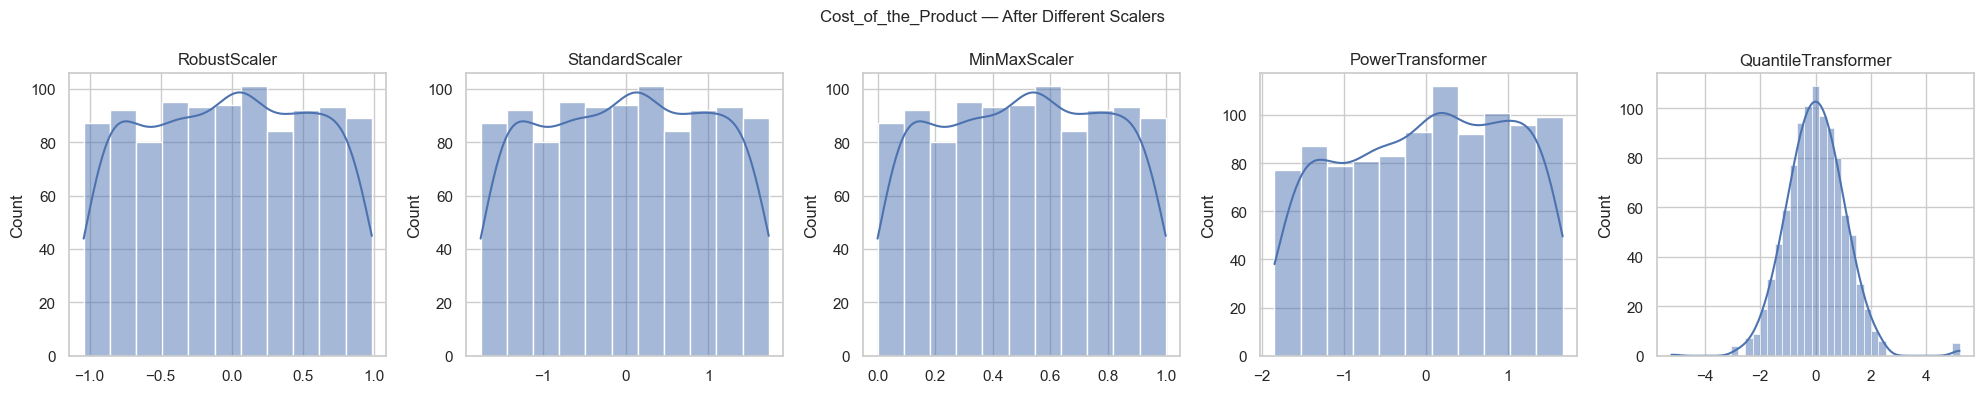

In [6]:
# Scaling comparison
scalers = {
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'PowerTransformer': PowerTransformer(),
    'QuantileTransformer': QuantileTransformer(output_distribution='normal')
}

fig, axes = plt.subplots(1, len(scalers), figsize=(20, 4))
fig.suptitle('Cost_of_the_Product — After Different Scalers', fontsize=12)

for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = scaler.fit_transform(X_num[['Cost_of_the_Product']])
    sns.histplot(scaled.flatten(), kde=True, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [7]:
# Anomaly detection with IsolationForest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_num)

n_anomalies = (anomaly_labels == -1).sum()
print(f"Anomalies detected: {n_anomalies} ({n_anomalies/len(df)*100:.1f}%)")

Anomalies detected: 50 (5.0%)


In [8]:
# VarianceThreshold — remove zero/low variance features
selector_var = VarianceThreshold(threshold=0.0)
selector_var.fit(X_num)
print(f"Features kept after VarianceThreshold: {selector_var.get_support().sum()} / {X_num.shape[1]}")

Features kept after VarianceThreshold: 6 / 6


In [9]:
# Final preprocessing overview
print("Preprocessing pipeline options explored:")
print("  Imputation: SimpleImputer, KNNImputer, IterativeImputer")
print("  Scaling: RobustScaler, StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer")
print("  Anomaly: IsolationForest")
print("  Feature Reduction: VarianceThreshold, SelectKBest, PCA")

Preprocessing pipeline options explored:
  Imputation: SimpleImputer, KNNImputer, IterativeImputer
  Scaling: RobustScaler, StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
  Anomaly: IsolationForest
  Feature Reduction: VarianceThreshold, SelectKBest, PCA
